In [8]:
!pip install transformers datasets evaluate wandb accelerate

In [23]:
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
)
import evaluate
import numpy as np
import wandb

# -----------------------------
# 1. W&B 初期化
# -----------------------------
wandb.init(
    project="transformer-fine-tuning",
    name="bert-mrpc-analysis",
    config={
        "model_name": "bert-base-uncased",
        "dataset": "glue/mrpc",
        "num_train_epochs": 3,
        "train_batch_size": 16,
        "eval_batch_size": 16,
        "eval_steps": 50,
        "save_steps": 100,
        "logging_steps": 10,
    },
)

# -----------------------------
# 2. データセット読み込み
# -----------------------------
raw_datasets = load_dataset("glue", "mrpc")

# -----------------------------
# 3. モデルとトークナイザの準備
# -----------------------------
checkpoint = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

model = AutoModelForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=2
)

# -----------------------------
# 4. 前処理関数
# -----------------------------
def preprocess_function(examples):
    return tokenizer(
        examples["sentence1"],
        examples["sentence2"],
        truncation=True,
    )

tokenized_datasets = raw_datasets.map(
    preprocess_function,
    batched=True
)

# Trainer で不要な文字列列があっても普通は自動で除外されますが、
# 明示的に残したくない場合は remove_columns してもOKです。
# tokenized_datasets = tokenized_datasets.remove_columns(["sentence1", "sentence2", "idx"])

# -----------------------------
# 5. Data collator
# -----------------------------
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# -----------------------------
# 6. 評価指標
# -----------------------------
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_metric.compute(predictions=predictions, references=labels)
    f1 = f1_metric.compute(predictions=predictions, references=labels)

    return {
        "accuracy": accuracy["accuracy"],
        "f1": f1["f1"],
    }

# -----------------------------
# 7. TrainingArguments
# -----------------------------
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="steps",
    eval_steps=50,
    save_strategy="steps",
    save_steps=100,
    logging_strategy="steps",
    logging_steps=10,
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    report_to="wandb",
    logging_dir="./logs",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
)

# -----------------------------
# 8. Trainer
# -----------------------------
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
)

# -----------------------------
# 9. 学習開始
# -----------------------------
trainer.train()

# -----------------------------
# 10. 最終評価
# -----------------------------
eval_results = trainer.evaluate()
print(eval_results)

wandb.log({"final_eval_accuracy": eval_results["eval_accuracy"]})
wandb.log({"final_eval_f1": eval_results["eval_f1"]})
wandb.finish()

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Step,Training Loss,Validation Loss,Accuracy,F1
50,0.586898,0.543136,0.737745,0.824877
100,0.462004,0.440167,0.813725,0.870307
150,0.490466,0.490339,0.781863,0.859400
200,0.394921,0.388000,0.833333,0.877698
250,0.287780,0.372726,0.840686,0.884135
300,0.212889,0.434770,0.823529,0.877133
350,0.228104,0.384170,0.835784,0.877960
400,0.188034,0.454927,0.850490,0.897479
450,0.255012,0.431879,0.833333,0.876364
500,0.046594,0.631388,0.848039,0.898361


There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

{'eval_loss': 0.6295605897903442, 'eval_accuracy': 0.8455882352941176, 'eval_f1': 0.896551724137931, 'eval_runtime': 2.0255, 'eval_samples_per_second': 201.428, 'eval_steps_per_second': 12.836, 'epoch': 3.0}


eval/accuracy,▁▆▄▇▇▆▇█▇████▇
eval/f1,▁▅▄▆▇▆▆█▆██▇██
eval/loss,▆▃▄▁▁▃▁▃▃█▇▇▇█
eval/runtime,▁▄▇█▃▇▅▅▁█▃▄▂▅
eval/samples_per_second,█▅▂▁▆▂▄▄█▁▅▅▇▄
eval/steps_per_second,█▅▂▁▆▂▄▄█▁▅▅▇▄
final_eval_accuracy,▁
final_eval_f1,▁
train/epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▇▇▇▇▇██
train/global_step,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇█████
+3,...


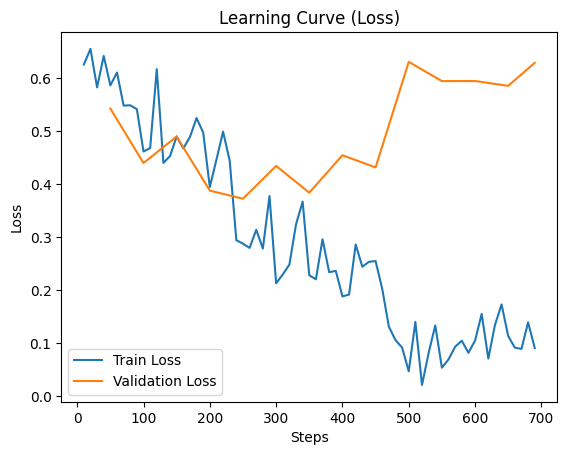

In [24]:
import matplotlib.pyplot as plt

# Trainer のログ履歴を取得
logs = trainer.state.log_history

train_loss = []
eval_loss = []
steps_train = []
steps_eval = []

for log in logs:
    if "loss" in log and "eval_loss" not in log:
        train_loss.append(log["loss"])
        steps_train.append(log["step"])
    if "eval_loss" in log:
        eval_loss.append(log["eval_loss"])
        steps_eval.append(log["step"])

# -----------------------------
# プロット
# -----------------------------
plt.figure()
plt.plot(steps_train, train_loss, label="Train Loss")
plt.plot(steps_eval, eval_loss, label="Validation Loss")

plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Learning Curve (Loss)")
plt.legend()
plt.show()

In [21]:
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
)
import evaluate
import numpy as np
import wandb

# -----------------------------
# 1. W&B 初期化
# -----------------------------
wandb.init(project="transformer-fine-tuning", name="bert-mrpc-analysis")

# -----------------------------
# 2. データセット読み込み
# GLUE の MRPC は文ペア分類タスク
# sentence1, sentence2 から
# 2文が意味的に同じかどうかを判定する
# -----------------------------
raw_datasets = load_dataset("glue", "mrpc")

# -----------------------------
# 3. モデルとトークナイザの準備
# 2クラス分類なので num_labels=2
# -----------------------------
checkpoint = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

model = AutoModelForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=2
)

# -----------------------------
# 4. 前処理関数
# sentence1 と sentence2 をまとめてトークナイズ
# truncation=True で長すぎる入力を切る
# -----------------------------
def preprocess_function(examples):
    return tokenizer(
        examples["sentence1"],
        examples["sentence2"],
        truncation=True,
    )

tokenized_datasets = raw_datasets.map(
    preprocess_function,
    batched=True
)

# -----------------------------
# 5. Data collator
# バッチごとに動的 padding を行う
# -----------------------------
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# -----------------------------
# 6. 評価指標
# MRPC では accuracy と f1 を見ることが多い
# -----------------------------
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_metric.compute(predictions=predictions, references=labels)
    f1 = f1_metric.compute(predictions=predictions, references=labels)

    return {
        "accuracy": accuracy["accuracy"],
        "f1": f1["f1"],
    }
# Example of detecting overfitting with early stopping
from transformers import EarlyStoppingCallback

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="steps",
    eval_steps=100,
    save_strategy="steps",
    save_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    num_train_epochs=10,  # Set high, but we'll stop early
)

# Add early stopping to prevent overfitting
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

# -----------------------------
# 9. 学習開始
# -----------------------------
trainer.train()

# -----------------------------
# 10. 最終評価
# -----------------------------
eval_results = trainer.evaluate()
print(eval_results)

eval/accuracy,▁▃▄▆▇▆▇▇██▇███
eval/f1,▁▃▄▅▆▅▆▇██▇███
eval/loss,█▆▅▄▃▅▃▅▁▅▇▇▆▆
eval/runtime,▂▄▂▂▁▆█▃▂▂▂▄▃▁
eval/samples_per_second,▇▅▇▆▇▂▁▆▇▇▇▅▆█
eval/steps_per_second,▇▅▇▆█▂▁▆▇▇▇▅▆█
train/epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇███
train/global_step,▁▁▂▂▂▂▂▂▂▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇█
train/grad_norm,▁▁▁▂▂▁▁▂▂▅▂▂▂▃▃▂▁▂▂▂▂▁▂▃▂▂▂▄▁▁▂▁▂▁▁▆▂▃█▁
train/learning_rate,█████▇▇▇▇▇▆▆▆▆▅▅▅▅▅▅▄▄▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▁▁▁
+1,...


BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss,Validation Loss,Accuracy,F1
100,No log,0.542763,0.762255,0.842276
200,No log,0.613788,0.696078,0.817647
300,No log,0.669539,0.602941,0.679842
400,No log,0.624084,0.683824,0.812227


There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

{'eval_loss': 0.5393264293670654, 'eval_accuracy': 0.7622549019607843, 'eval_f1': 0.8438003220611916, 'eval_runtime': 2.0191, 'eval_samples_per_second': 202.071, 'eval_steps_per_second': 25.259, 'epoch': 0.8714596949891068}


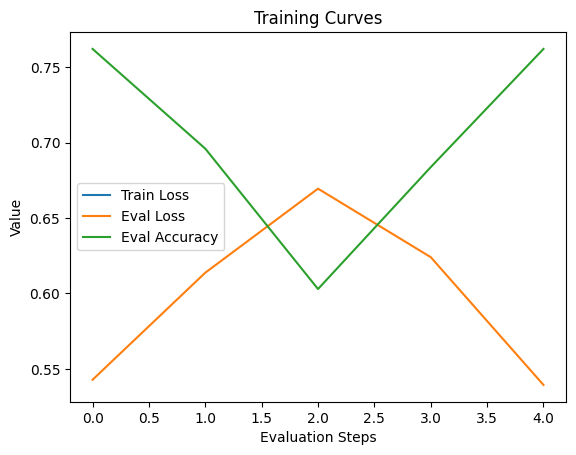

In [22]:
import matplotlib.pyplot as plt

# Trainerのログ履歴を取得
logs = trainer.state.log_history

train_loss = []
eval_loss = []
eval_accuracy = []
steps = []

for log in logs:
    if "loss" in log:
        train_loss.append(log["loss"])
        steps.append(log["step"])
    if "eval_loss" in log:
        eval_loss.append(log["eval_loss"])
    if "eval_accuracy" in log:
        eval_accuracy.append(log["eval_accuracy"])

# ---- Plot ----
plt.figure()

# Loss
plt.plot(train_loss, label="Train Loss")
plt.plot(eval_loss, label="Eval Loss")

# Accuracy（別軸にするのもアリ）
plt.plot(eval_accuracy, label="Eval Accuracy")

plt.xlabel("Evaluation Steps")
plt.ylabel("Value")
plt.legend()
plt.title("Training Curves")
plt.show()